# [LAB-13] 시계열 데이터의 탐색

In [1]:
from statsmodels.tsa.stattools import adfuller

from statsmodels.tsa.seasonal import seasonal_decompose

from pandas import DataFrame

In [2]:
origin = load_data("air_passengers")
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/lab13_/air_passengers.xlsx
[desc] 어느 항공사의 월간 탑승객 수 (출처: https://www.kaggle.com/datasets/rakannimer/air-passengers)
[!] Cannot read metadata

===== 데이터 크기 확인 =====
데이터셋 크기: (144, 2)
열 개수: 2
행 개수: 144

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Month       144 non-null    datetime64[ns]
 1   Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB
None


,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [3]:
df1 = origin.set_index("Month")
df1.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


====0차 차분====


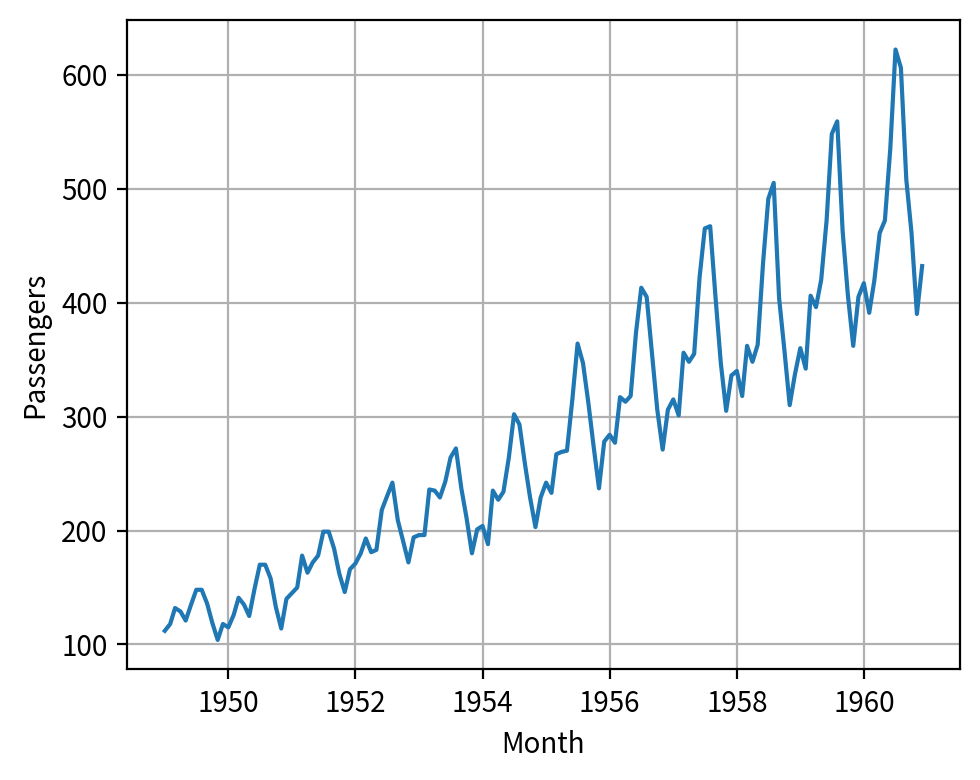

,0
ADF Statistic,0.815369
P-value,0.99188
num of lags,13
num of observation,130
result,False


====1차 차분====


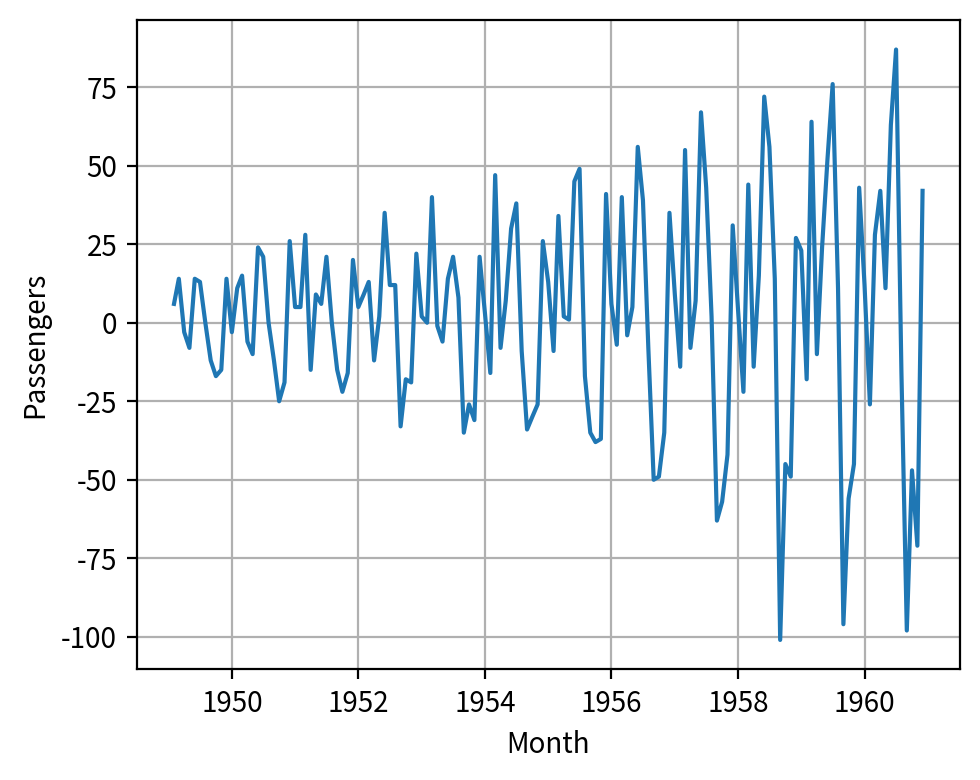

,0
ADF Statistic,-2.829267
P-value,0.054213
num of lags,12
num of observation,130
result,False


====2차 차분====


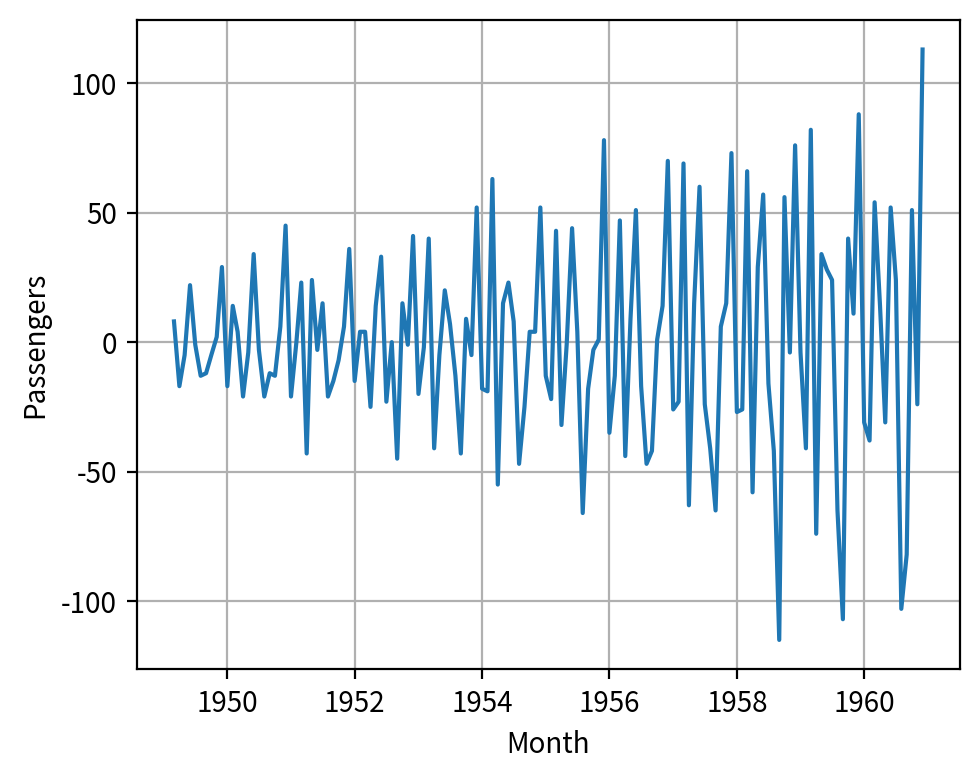

,0
ADF Statistic,-16.384232
P-value,0.0
num of lags,11
num of observation,130
result,True


In [5]:
diff_df = df1.copy()
yname = "Passengers"
count = 0

while True:
    print(f"===={count}차 차분====")
    # 1) 그래프 초기화 (캔바스(fig)와 도화지(ax) 준비하기)
    width_px = 1000
    height_px = 800
    rows = 1
    cols = 1
    figsize = (width_px / my_dpi, height_px / my_dpi)
    fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

    # 2) 그래프 그리기 -> seaborn 사용
    sb.lineplot(data=diff_df, x=diff_df.index, y=yname)

    # 3) 그래프 꾸미기
    ax.grid(True)

    plt.tight_layout()
    plt.show()
    plt.close()

    ar = adfuller(diff_df[yname])
    ar_dict = {
        "ADF Statistic": ar[0],
        "P-value": ar[1],
        "num of lags": ar[2],
        "num of observation": ar[3],
    }

    ar_dict["result"] = True if ar[1] <= 0.05 else False

    adf = DataFrame([ar_dict]).T
    display(adf)

    if ar[1] <= 0.05:
        break

    count += 1
    diff_df = diff_df.diff().dropna()

In [8]:
df2 = df1.copy()
df2["rolling3"] = df2["Passengers"].rolling(3).mean()
df2["rolling6"] = df2["Passengers"].rolling(6).mean()
df2["rolling9"] = df2["Passengers"].rolling(9).mean()
df2.head(10)

,Passengers,rolling3,rolling6,rolling9
Month,,,,
1949-01-01,112,NaN,NaN,NaN
1949-02-01,118,NaN,NaN,NaN
1949-03-01,132,120.666667,NaN,NaN
1949-04-01,129,126.333333,NaN,NaN
1949-05-01,121,127.333333,NaN,NaN
1949-06-01,135,128.333333,124.500000,NaN
1949-07-01,148,134.666667,130.500000,NaN
1949-08-01,148,143.666667,135.500000,NaN
1949-09-01,136,144.000000,136.166667,131.000000


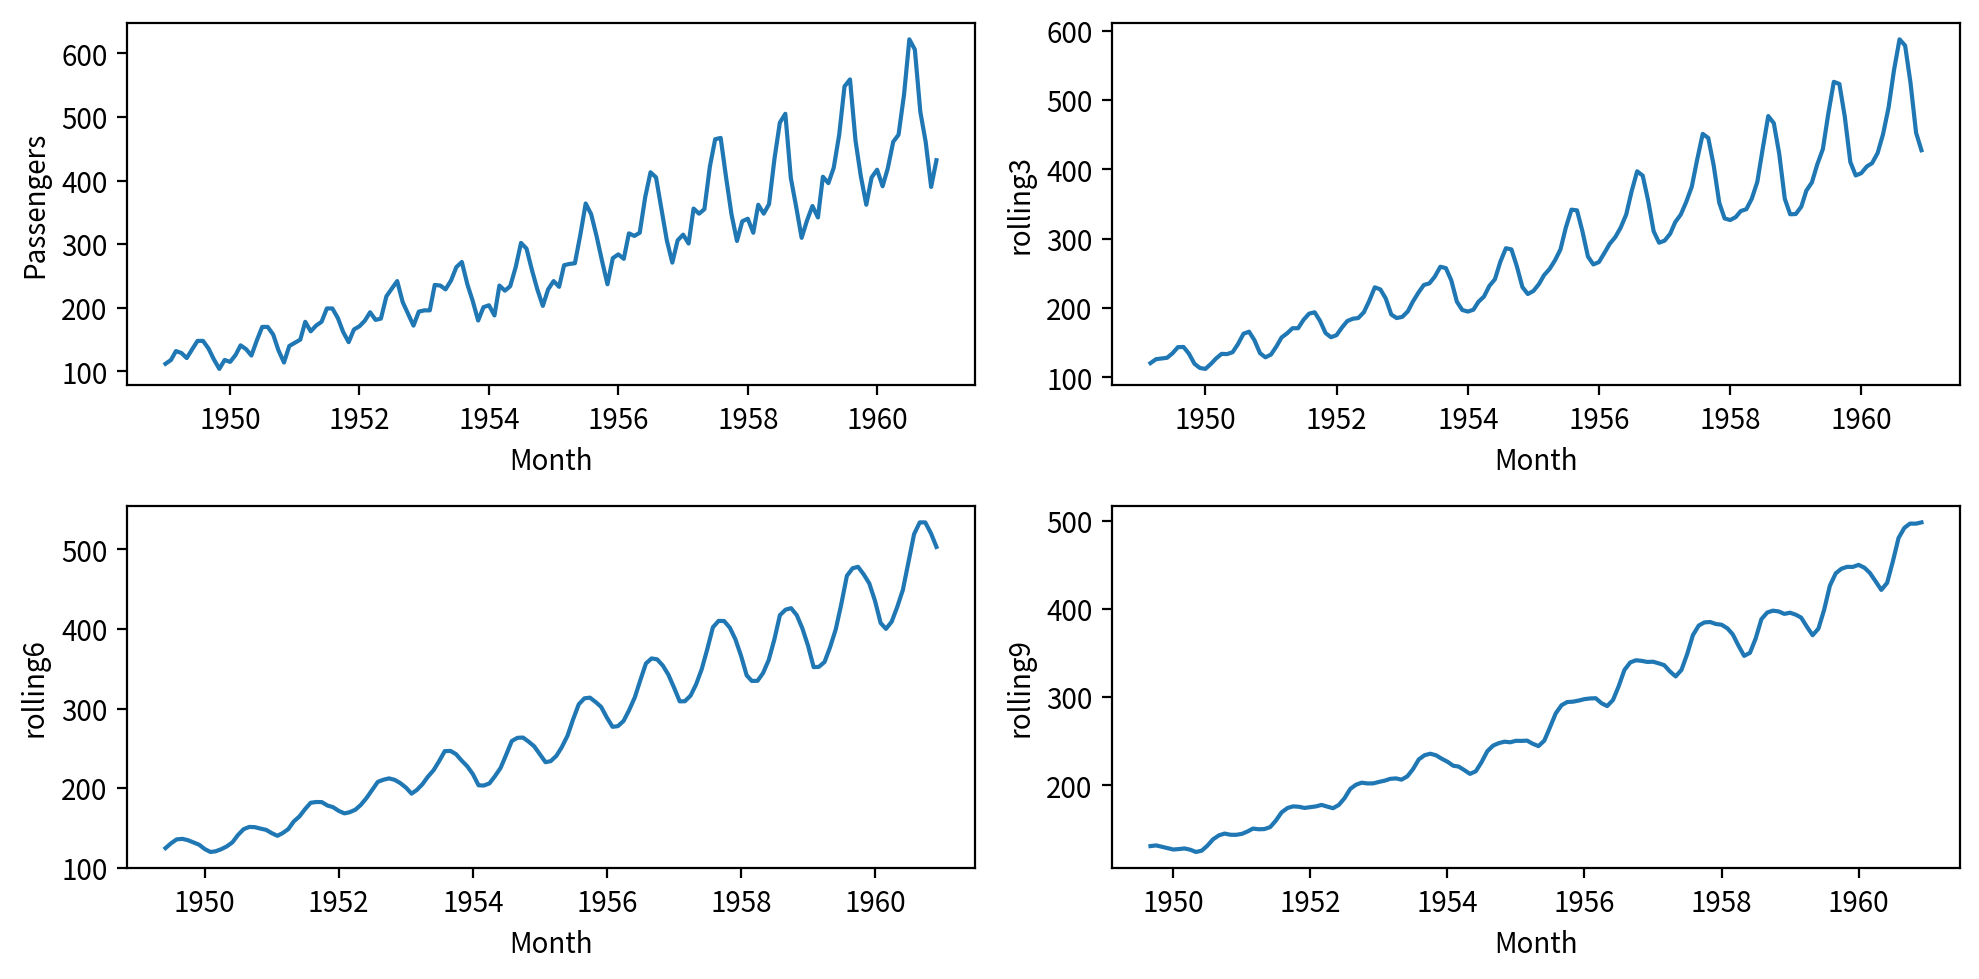

In [10]:
# 1) 그래프 초기화 (캔바스(fig)와 도화지(ax) 준비하기)
width_px = 2000
height_px = 1000
rows = 2
cols = 2
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

# 2) 그래프 그리기 -> seaborn 사용
sb.lineplot(data=df2, x=df2.index, y="Passengers", ax=ax[0][0])
sb.lineplot(data=df2, x=df2.index, y="rolling3", ax=ax[0][1])
sb.lineplot(data=df2, x=df2.index, y="rolling6", ax=ax[1][0])
sb.lineplot(data=df2, x=df2.index, y="rolling9", ax=ax[1][1])


plt.tight_layout()
plt.show()
plt.close()

In [12]:
df3 = diff_df.copy()

df3["rolling3"] = df3["Passengers"].rolling(3).mean()
df3["rolling6"] = df3["Passengers"].rolling(6).mean()
df3["rolling9"] = df3["Passengers"].rolling(9).mean()
df3.head(10)

,Passengers,rolling3,rolling6,rolling9
Month,,,,
1949-03-01,8.0,NaN,NaN,NaN
1949-04-01,-17.0,NaN,NaN,NaN
1949-05-01,-5.0,-4.666667,NaN,NaN
1949-06-01,22.0,0.000000,NaN,NaN
1949-07-01,-1.0,5.333333,NaN,NaN
1949-08-01,-13.0,2.666667,-1.000000,NaN
1949-09-01,-12.0,-8.666667,-4.333333,NaN
1949-10-01,-5.0,-10.000000,-2.333333,NaN
1949-11-01,2.0,-5.000000,-1.166667,-2.333333


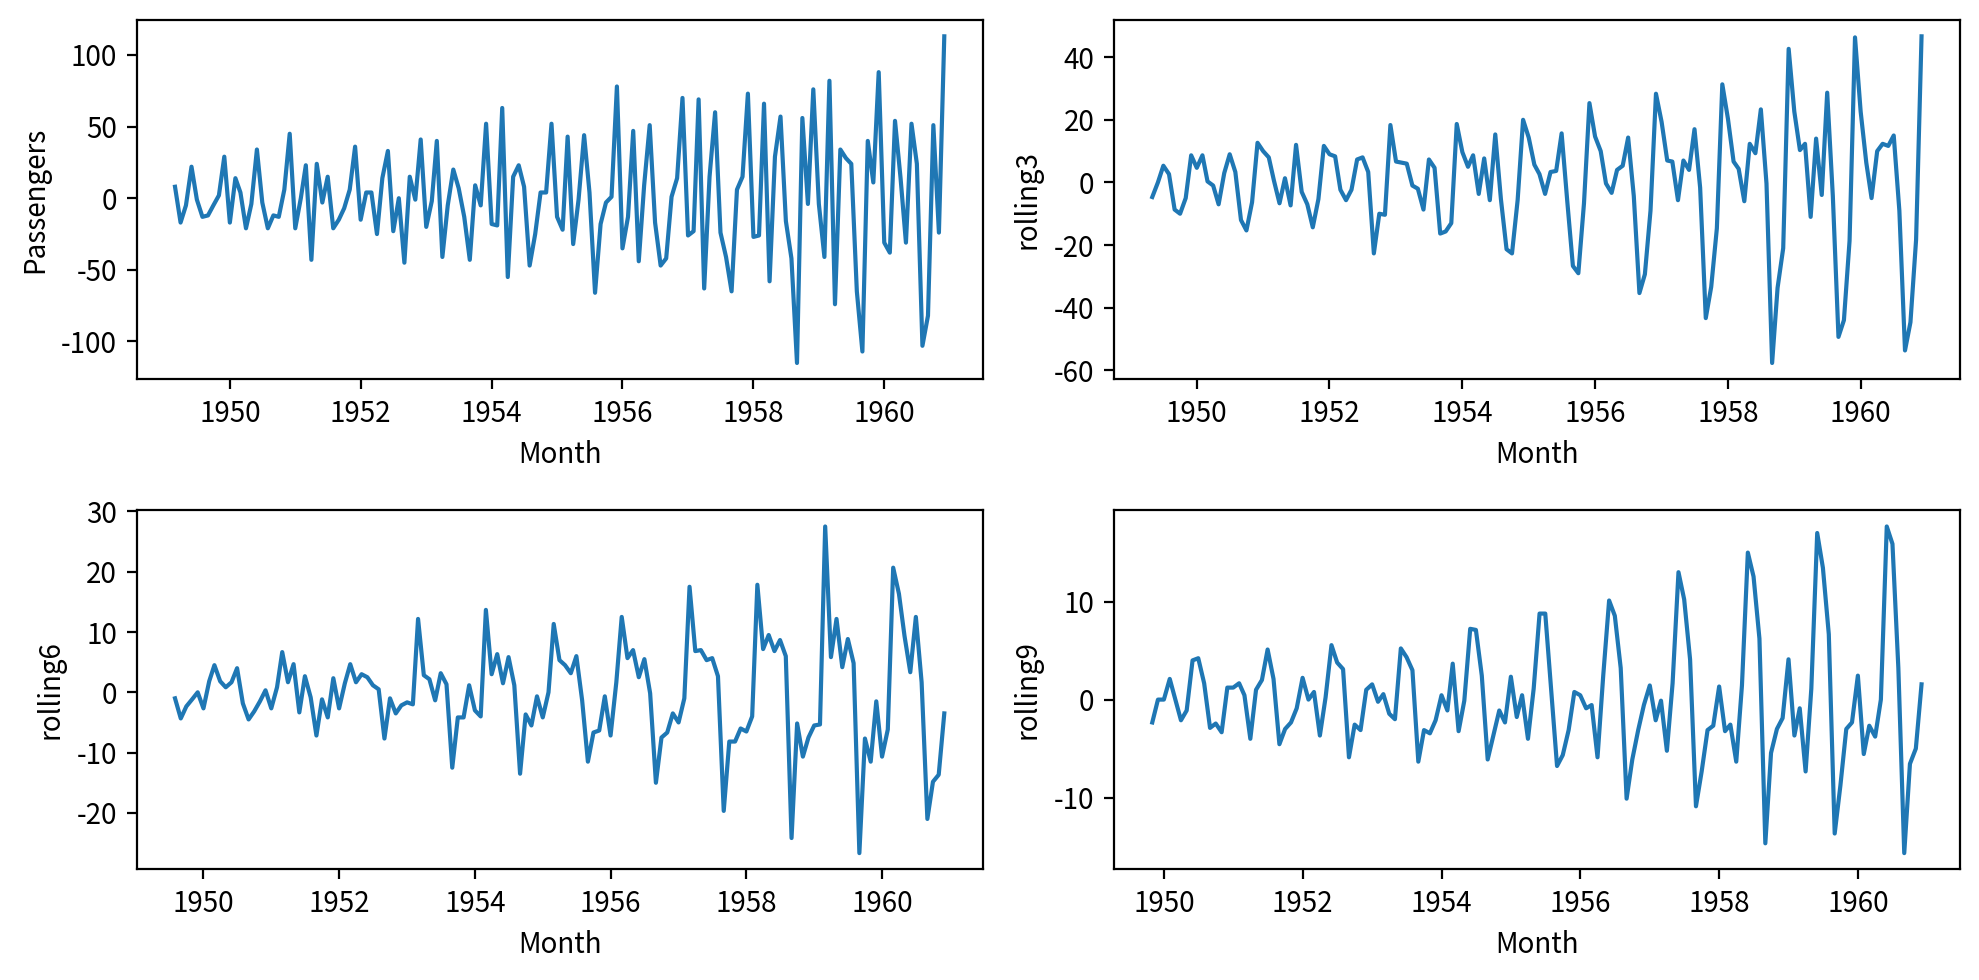

In [13]:
# 1) 그래프 초기화 (캔바스(fig)와 도화지(ax) 준비하기)
width_px = 2000
height_px = 1000
rows = 2
cols = 2
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

# 2) 그래프 그리기 -> seaborn 사용
sb.lineplot(data=df3, x=df3.index, y="Passengers", ax=ax[0][0])
sb.lineplot(data=df3, x=df3.index, y="rolling3", ax=ax[0][1])
sb.lineplot(data=df3, x=df3.index, y="rolling6", ax=ax[1][0])
sb.lineplot(data=df3, x=df3.index, y="rolling9", ax=ax[1][1])


plt.tight_layout()
plt.show()
plt.close()

In [22]:
df4 = df1.copy()

df4["ewm3"] = df4["Passengers"].ewm(3).mean()
df4["ewm6"] = df4["Passengers"].ewm(6).mean()
df4["ewm9"] = df4["Passengers"].ewm(9).mean()
df3.head(10)

,Passengers,rolling3,rolling6,rolling9
Month,,,,
1949-03-01,8.0,NaN,NaN,NaN
1949-04-01,-17.0,NaN,NaN,NaN
1949-05-01,-5.0,-4.666667,NaN,NaN
1949-06-01,22.0,0.000000,NaN,NaN
1949-07-01,-1.0,5.333333,NaN,NaN
1949-08-01,-13.0,2.666667,-1.000000,NaN
1949-09-01,-12.0,-8.666667,-4.333333,NaN
1949-10-01,-5.0,-10.000000,-2.333333,NaN
1949-11-01,2.0,-5.000000,-1.166667,-2.333333


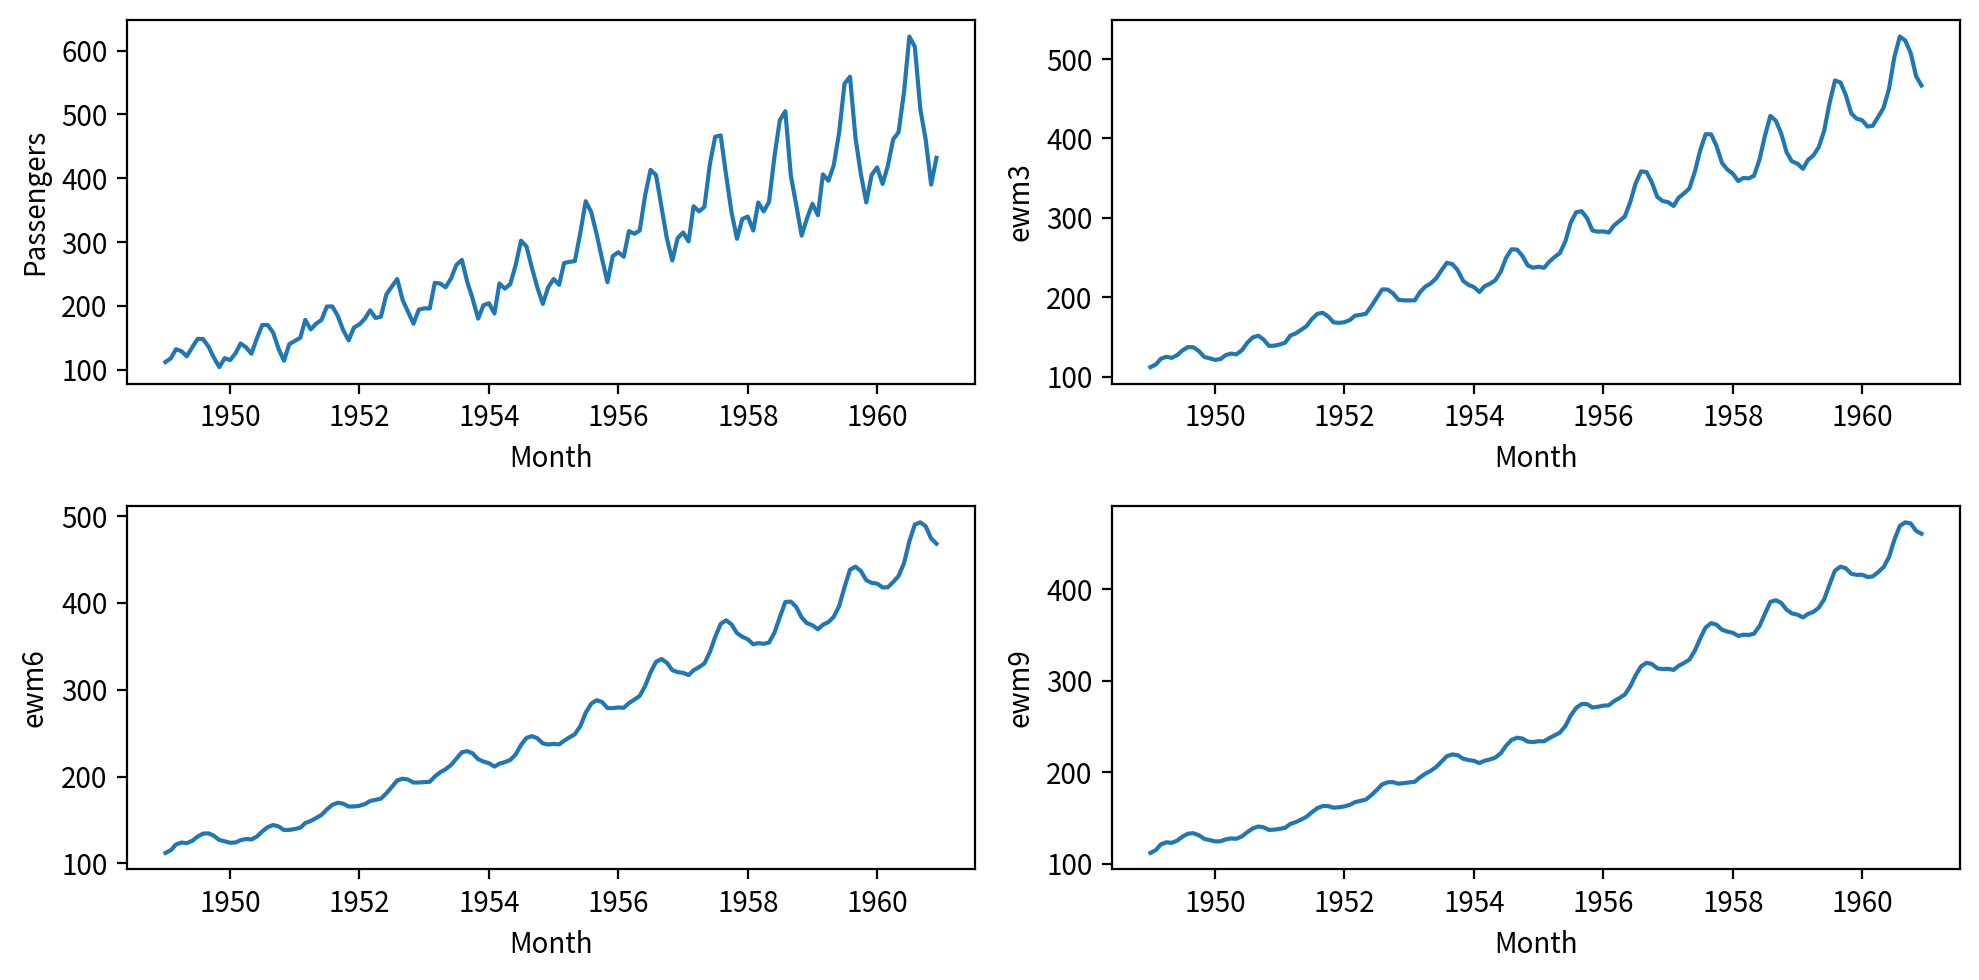

In [23]:
# 1) 그래프 초기화 (캔바스(fig)와 도화지(ax) 준비하기)
width_px = 2000
height_px = 1000
rows = 2
cols = 2
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

# 2) 그래프 그리기 -> seaborn 사용
sb.lineplot(data=df4, x=df4.index, y="Passengers", ax=ax[0][0])
sb.lineplot(data=df4, x=df4.index, y="ewm3", ax=ax[0][1])
sb.lineplot(data=df4, x=df4.index, y="ewm6", ax=ax[1][0])
sb.lineplot(data=df4, x=df4.index, y="ewm9", ax=ax[1][1])


plt.tight_layout()
plt.show()
plt.close()

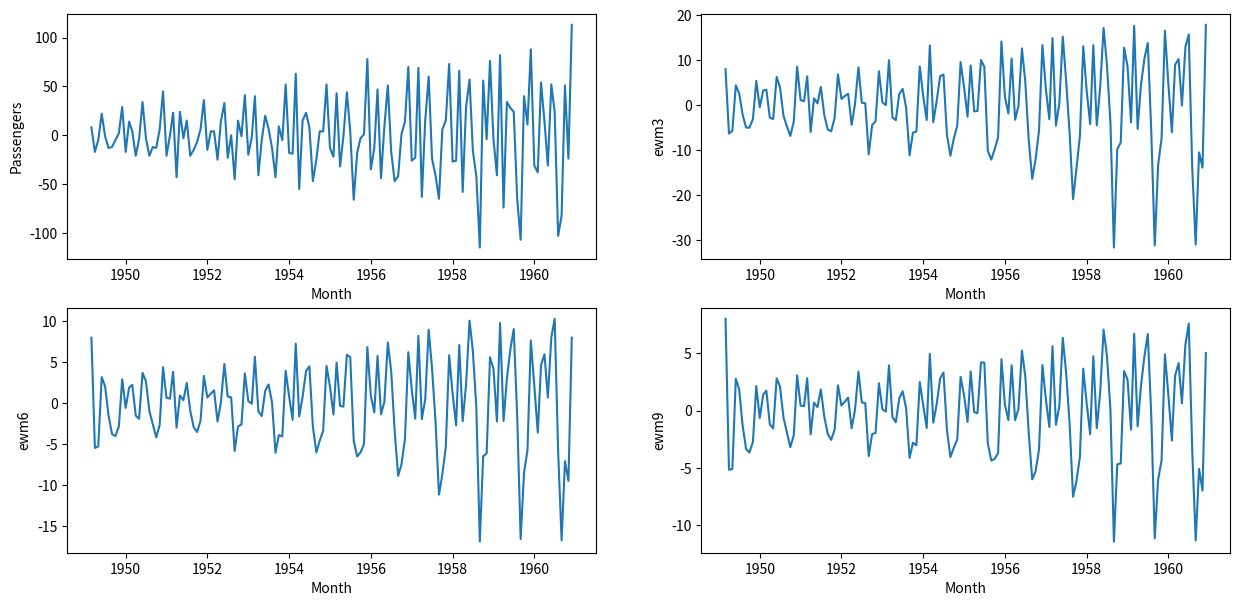

In [24]:
diff_df["ewm3"] = diff_df["Passengers"].ewm(3).mean()
diff_df["ewm6"] = diff_df["Passengers"].ewm(6).mean()
diff_df["ewm9"] = diff_df["Passengers"].ewm(9).mean()

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 7))

sb.lineplot(data=diff_df, x=diff_df.index, y="Passengers", ax=ax1)
sb.lineplot(data=diff_df, x=diff_df.index, y="ewm3", ax=ax2)
sb.lineplot(data=diff_df, x=diff_df.index, y="ewm6", ax=ax3)
sb.lineplot(data=diff_df, x=diff_df.index, y="ewm9", ax=ax4)

plt.show()
plt.close()

In [ ]:
# model_name = 'additive' # 가법모델
model_name = "multiplicative" # 승법 모델

sd = seasonal_decompose(df1["Passengers"], model=model_name)

In [28]:
sd_df = DataFrame(
    {
        "original": sd.observed,
        "trend": sd.trend,
        "seasonal": sd.seasonal,
        "resid": sd.resid,
    },
    index=origin.index,
)

sd_df

,original,trend,seasonal,resid
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN
...,...,...,...,...
139,NaN,NaN,NaN,NaN
140,NaN,NaN,NaN,NaN
141,NaN,NaN,NaN,NaN
142,NaN,NaN,NaN,NaN


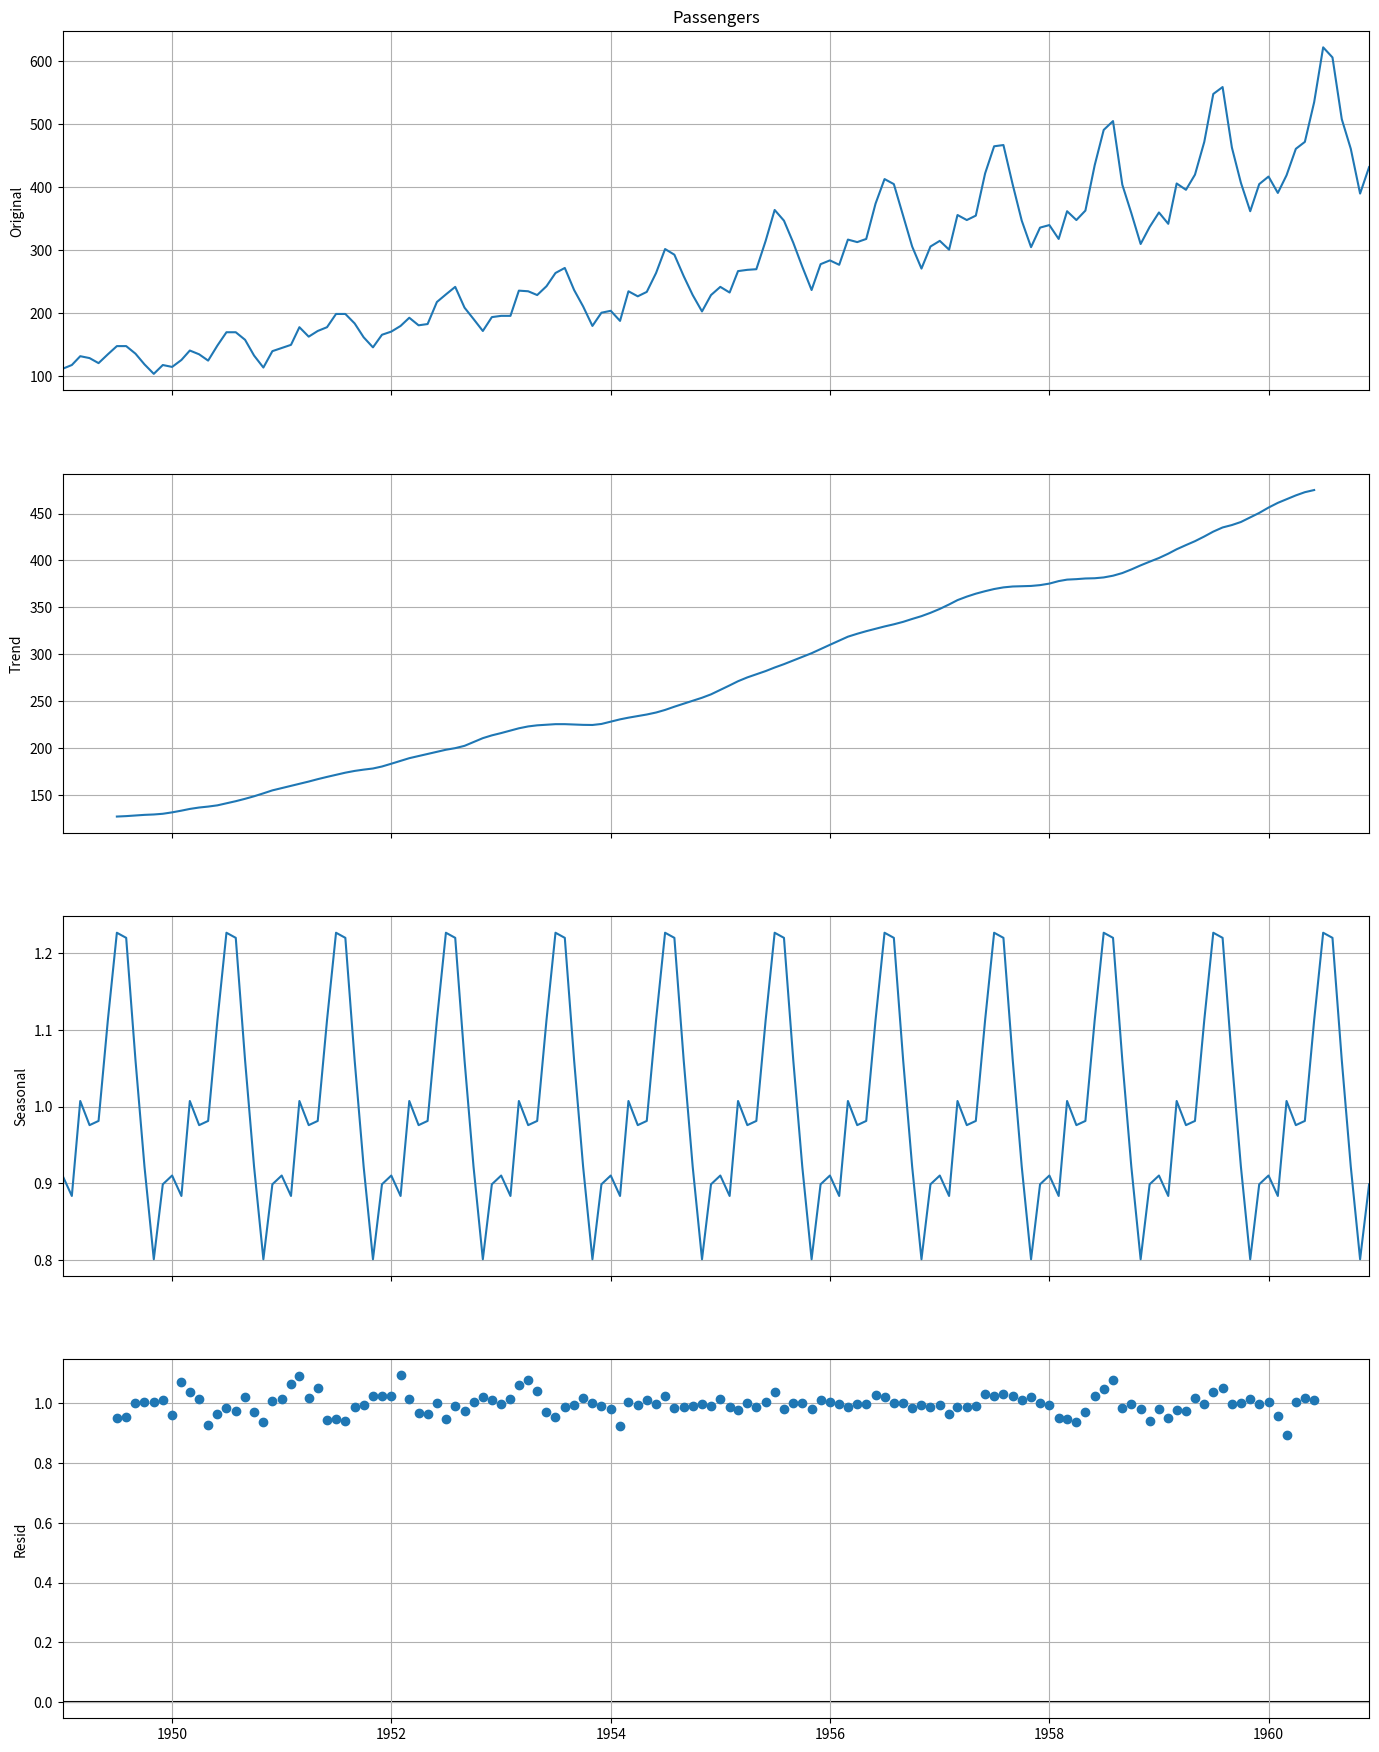

In [31]:
figure = sd.plot()
figure.set_size_inches((15, 20))

fig, ax1, ax2, ax3, ax4 = figure.get_children()

ax1.set_ylabel("Original")
ax1.grid(True)
ax2.grid(True)
ax3.grid(True)
ax4.grid(True)

plt.show()
plt.close()